In [8]:
from pulse_counter_diabatic.counter_diabatic import CounterDiabaticPulse
from pulse_counter_diabatic.rydberg_to_ising import from_ising_to_rydberg, from_rydberg_to_seq

import pulser
import torch
import emu_sv


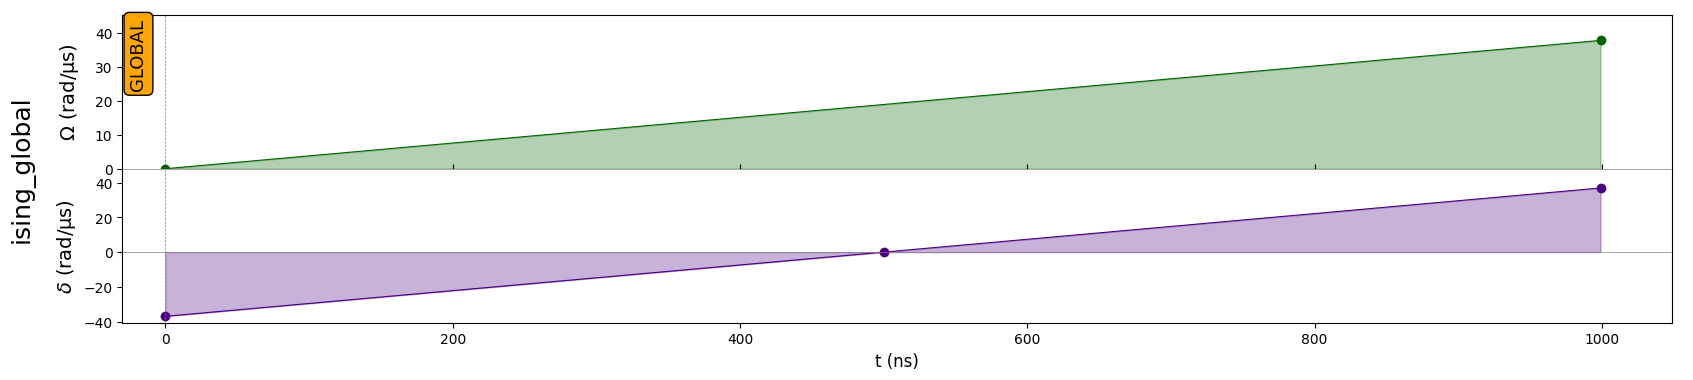

In [9]:
om_max_rabi = 1 * torch.pi * 4.0
num_atoms = 1

reg = pulser.Register.rectangle(1, num_atoms, prefix="q",spacing=7.0)

T = 1000
delta_0 = -37
delta_f = 37
adiabatic_pulse = pulser.Pulse(
    pulser.InterpolatedWaveform(T, [1e-9, 3*om_max_rabi]),
    pulser.InterpolatedWaveform(T, [delta_0, 0, delta_f]),
    0,
)
seq = pulser.Sequence(reg, pulser.MockDevice)
seq.declare_channel("ising_global", "rydberg_global")
seq.add(adiabatic_pulse, "ising_global")
seq.draw()

In [10]:
dt = 10
eval_times = [1.0]
sv_config_normal = emu_sv.SVConfig(
        dt=dt,
        observables=[
            emu_sv.Occupation(evaluation_times=eval_times),
            emu_sv.BitStrings(evaluation_times=eval_times, num_shots=1000),
            #emu_mps.Energy(evaluation_times=eval_times),
            #emu_mps.EnergyVariance(evaluation_times=eval_times),
            #emu_mps.EnergySecondMoment(evaluation_times=eval_times),
            #emu_mps.CorrelationMatrix(evaluation_times=eval_times),
            emu_sv.StateResult(evaluation_times=eval_times),
            #emu_mps.Fidelity(evaluation_times=eval_times, state=fidelity_state, tag_suffix="1"),
        ],
        #noise_model=noise_model,
        #interaction_cutoff=interaction_cutoff,
        #optimize_qubit_ordering=optimize_qubit_ordering,
        #solver=solver,
    log_level=100)

backend = emu_sv.SVBackend(seq, config=sv_config_normal)

result = backend.run()

In [11]:
ocupation = result.occupation[-1]
print(ocupation)
bitstrings = result.bitstrings[-1]
print(bitstrings)

tensor([0.8053], dtype=torch.float64)
Counter({'1': 817, '0': 183})


## Improve the pulse

In [15]:
cd_seq = CounterDiabaticPulse(seq,sv_config_normal)
omega_cd, mus_cd, nus_cd, ising_interaction_mat = cd_seq.solver(nruns=1)
omegas_rydberg, mus_rydberg, nus_rydberg, interaction_mat_rydberg = from_ising_to_rydberg(omega_cd, mus_cd, nus_cd,ising_interaction_mat)

step    0  loss = 0.000000e+00
Early stopping at step 0 with loss 0.000000


In [13]:
omegas_seq, deltas_seq, phis_seq, = from_rydberg_to_seq(omegas_rydberg, mus_rydberg, nus_rydberg)

In [14]:
import emu_base
import dataclasses
from emu_sv.sv_backend_impl import SVBackendImpl

eval_times = [1.0]
sv_config_cd = emu_sv.SVConfig(
      dt=dt,

      observables=[
          emu_sv.Occupation(evaluation_times=eval_times),
          emu_sv.BitStrings(evaluation_times=eval_times, num_shots=1000),
          emu_sv.StateResult(evaluation_times=eval_times),
      ],
      log_level=100,
  )

pulser_data_cd = emu_base.PulserData(sequence=seq, config=sv_config_cd, dt=dt)
sequence_data_cd = next(pulser_data_cd.get_sequences())

custom_data_cd = dataclasses.replace(
    sequence_data_cd,
    omega=omegas_seq.to(torch.complex128).detach(),
    delta=deltas_seq.to(torch.complex128).detach(),
    phi=phis_seq.to(torch.complex128).detach(),
)

impl_cd = SVBackendImpl(sv_config_cd, custom_data_cd)                                           
result_cd = impl_cd._run()                                                                        

print("Original")
print(result.bitstrings[-1])

print("CD corrected")
print(result_cd.bitstrings[-1])

Original
Counter({'1': 817, '0': 183})
CD corrected
Counter({'1': 794, '0': 206})
